## Simulación de un PID de forma iterativa

Librerías necesarias

In [18]:
import matplotlib.pyplot as plt

El Proceso a controlar viene descrito por el siguiente modelo discreto obtenido a un período de muestreo, T = 0.1 seg.

$$G_p(z)=\frac{0.007(z+0.94)}{(z-0.95)(z-0.86)}$$

Primero simularemos el comportamiento del proceso sin regulador en lazo cerrado

Expresamos dicha función de transferencia en la ecuación en diferencias equivalente:

$$y(k)=1.81y(k-1)-0.817y(k-2)+0.007u(k-1)+0.0066u(k-2)$$

Definimos las variables que van a almacenar los datos de la simulación así como otros parámetros:

In [19]:
tsim = 10               # Tiempo de simulación en segundos
T = 0.1 
ret = 2                # Período de muestreo
numiter = int(tsim/T)-ret   # Número de iteraciones para la simulación
entrada = []
error = []
accont = []
salida = []

La función 'simula()' obtiene los valores de la simulación para instantes despúes del retardo

In [20]:
def simula():
    global ym1, ym2, em1, em2
    for i in range(numiter):
        y = (1.81*ym1)-(0.817*ym2)+(0.007*em1)+(0.0066*em2)
        e = u - ym1
        entrada.append(u)
        error.append(e)
        salida.append(y)

        # Reasignamos las variables
        em2 = em1
        em1 = e
        ym2 = ym1
        ym1 = y

    # print (error)
    # print (salida)

Calculamos los dos primeros valores ya que provocarían índices negativos en el bucle al calcular y(k)

In [21]:
# Iteración k = 0
u = 1       # Entrada escalón unitario
ek = 0
yk = 0
entrada.append(u)
error.append(ek)
salida.append(yk)

# Iteración k = 1
ek1 = u - yk
yk1 = (1.81*yk)+(0.007*ek1)
entrada.append(u)
error.append(ek1)
salida.append(yk1)

# Iteración k = 2
ek2 = u - yk1
yk2 = (1.81*yk1)-(0.817*yk)+(0.007*ek2)+(0.0066*ek1)
entrada.append(u)
error.append(ek2)
salida.append(yk2)

# Resto de iteraciones
ym1 = yk2
ym2 = yk1
em1 = ek2
em2 = ek1

simula()


Realizamos la obtención del resto de valores mediante un bucle:

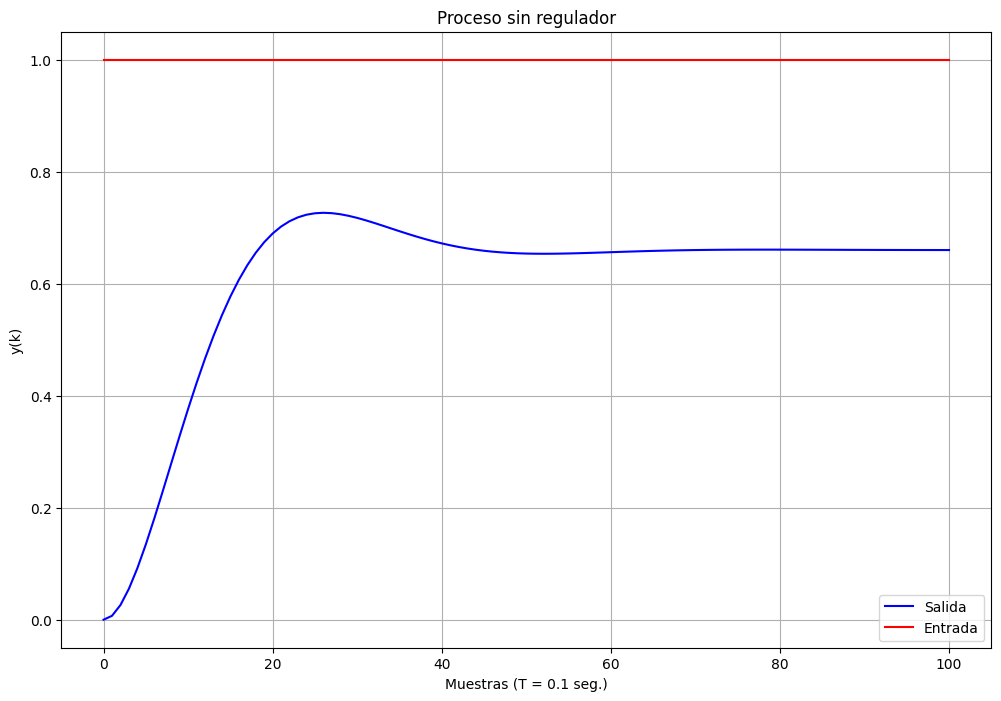

In [22]:
# Representar los datos
longitud_datos = len(salida)
ejex = []
for i in range(0, longitud_datos):
    ejex.append(i)

# print(len(datos))
# print(len(ejex))

plt.figure(figsize=(12, 8)) # Opcional: Define el tamaño de la figura
plt.plot(ejex, salida, label='Salida', color='blue', linestyle='solid') # Dibuja la línea
plt.plot(ejex, entrada, label='Entrada', color='red', linestyle='solid') # Dibuja la línea

# 3. Personalizar (opcional)
plt.title('Proceso sin regulador')
plt.xlabel('Muestras (T = 0.1 seg.)')
plt.ylabel('y(k)')
plt.legend() # Muestra la leyenda
plt.grid(True) # Añade una cuadrícula

# 4. Mostrar la gráfica
plt.show()        
